In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [2]:
class HeatPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.tanh = nn.Tanh()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

model = HeatPINN()

In [11]:
class Dataset_PDE(Dataset):
    def __init__(self):
        super().__init__()
        self.data = torch.randn(500, 2, requires_grad=True)

    def __len__(self):
        return self.data.shape[0]
    
    def __getitem__(self, index):
        return self.data[index]
    
dataset_train_PDE = Dataset_PDE()
dataloader_PDE = DataLoader(dataset_train_PDE, batch_size=32, shuffle=True)

In [28]:
dataset_train_IC = torch.stack((torch.zeros(101), torch.arange(0.0, 1.01, 0.01))).permute(1, 0)
dataset_train_IC.requires_grad = True
dataset_train_IC.shape

torch.Size([101, 2])

In [36]:
u_IC = torch.sin(torch.pi * torch.arange(0.0, 1.01, 0.01)).unsqueeze(1)
u_IC.requires_grad = True
u_IC.shape

torch.Size([101, 1])

In [ ]:
dataset_train_BC = torch.cat((torch.stack((torch.zeros(101), torch.linspace(0.0, 1.0, 101))), torch.stack((torch.ones(101), torch.linspace(0.0, 1.0, 101)))), dim=1).permute(1, 0)
dataset_train_BC.requires_grad = True
dataset_train_BC.shape

torch.Size([202, 2])

In [45]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [49]:
p, q = torch.tensor(1.0, requires_grad=True), torch.tensor(2.0, requires_grad=True)
f = p.pow(2) + q.pow(3) + p * q.pow(2)
f_p = autograd.grad(f, p, create_graph=True)[0]
f_p

tensor(6., grad_fn=<AddBackward0>)

In [52]:
f_q = autograd.grad(f, q, create_graph=True)[0]
f_q

tensor(16., grad_fn=<AddBackward0>)

In [54]:
f_pp = autograd.grad(f_p, p, create_graph=True)[0]
f_pp

tensor(2., grad_fn=<MulBackward0>)

In [55]:
f_qq = autograd.grad(f_q, q, create_graph=True)[0]
f_qq

tensor(14., grad_fn=<AddBackward0>)

In [83]:
x = torch.linspace(0.0, 1.0, 11, requires_grad=True)
g = x.pow(2)
g_x = autograd.grad(g.sum(), x, create_graph=True)[0]
g_x

tensor([0.0000, 0.2000, 0.4000, 0.6000, 0.8000, 1.0000, 1.2000, 1.4000, 1.6000,
        1.8000, 2.0000], grad_fn=<MulBackward0>)

In [84]:
g_xx = autograd.grad(g_x.sum(), x)[0]
g_xx

tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alpha = 0.1
epochs = 1000
model = model.to(device)
dataset_train_IC = dataset_train_IC.to(device)
dataset_train_BC = dataset_train_BC.to(device)
u_IC = u_IC.to(device)

for epoch in tqdm(range(epochs)):
    model.train()
    loss_pde, loss_ic, loss_bc, total_loss = 0, 0, 0, 0

    for batch in dataloader_PDE:
        batch = batch.to(device)
        optimizer.zero_grad()

        u_pde = model(batch)
        du_dt_du_dx = autograd.grad(u_pde.sum(), batch, create_graph=True)[0]
        du_dt = du_dt_du_dx[:, 0]
        du_dx = du_dt_du_dx[:, 1]

        du_dxx = autograd.grad(du_dx.sum(), batch, create_graph=True)[0][:, 1]
        loss_pde = torch.mean((du_dt - alpha*du_dxx)**2)

        u_ic = model(dataset_train_IC)
        loss_ic = torch.mean((u_IC - u_ic)**2)

        u_bc = model(dataset_train_BC)
        loss_bc = torch.mean(u_bc**2)

        total_loss = loss_pde + loss_ic + loss_bc

        total_loss.backward()
        optimizer.step()
    
    if(epoch % 100 == 0):
        print(f'Epoch {epoch}')
        print(loss_pde.item(), loss_ic.item(), loss_bc.item())
        print(total_loss.item())


  0%|          | 2/1000 [00:00<02:23,  6.94it/s]

Epoch 0
0.001156739192083478 0.05984613299369812 0.10852731764316559
0.16953018307685852


 10%|█         | 101/1000 [00:16<03:32,  4.24it/s]

Epoch 100
0.000715510337613523 0.05239375680685043 0.11600317806005478
0.1691124439239502


 20%|██        | 202/1000 [00:31<01:12, 11.02it/s]

Epoch 200
0.0018912827363237739 0.05800639092922211 0.11018163710832596
0.170079305768013


 24%|██▎       | 237/1000 [00:34<01:50,  6.89it/s]


KeyboardInterrupt: 

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


0.049608707427978516


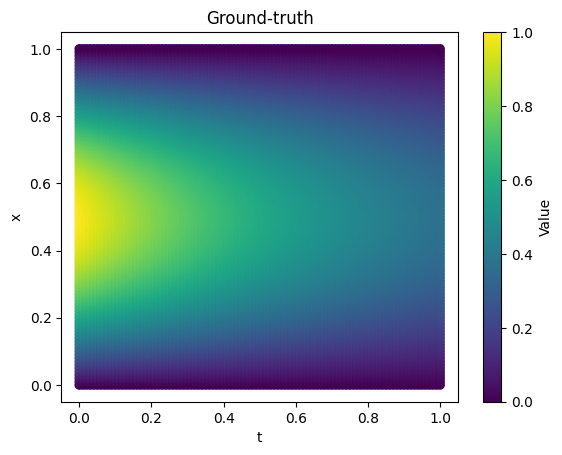

Text(0.5, 1.0, 'Predicted')

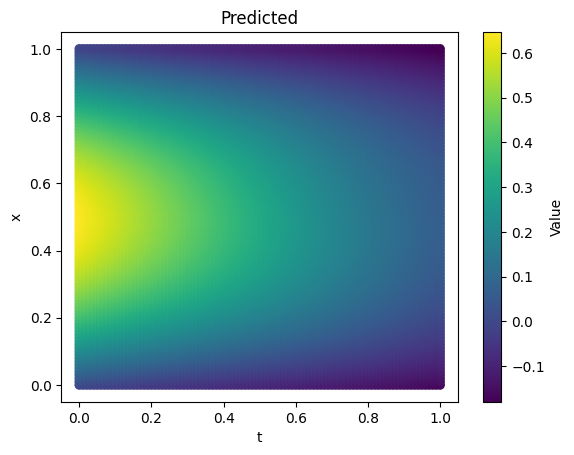

In [110]:
model.to('cpu')
data_1dim = torch.linspace(0, 1, 101)
data_grid = torch.meshgrid(data_1dim, data_1dim)
tx_test = torch.stack([data_grid[0].reshape(-1), data_grid[1].reshape(-1)], dim=1)
u_test = torch.exp(- alpha * torch.pi**2 * tx_test[:,0]) * torch.sin(torch.pi * tx_test[:,1])
U_test = model(tx_test).reshape(-1).detach()

mse = torch.mean((u_test - U_test)**2).item()
print(mse)

plt.figure(1)
plt.scatter(tx_test[:,0], tx_test[:,1], c=u_test, cmap='viridis')
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.title('Ground-truth')

plt.show()

plt.figure(2)
plt.scatter(tx_test[:,0], tx_test[:,1], c=U_test, cmap='viridis')
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.title('Predicted')